# 03 Model Evaluation

Error analysis of the final model using out of fold predictions: every song is scored by
the one fold model that never trained on it, so pooling the five folds gives one honest
prediction per song for all 1,628 songs. `src/evaluation/predict.py` rebuilds those
predictions from each fold's saved preprocessor and best checkpoint, scoring songs
exactly the way training did (window the roll, average the window probabilities).

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))  # make `import src...` work from notebooks/
os.chdir(REPO_ROOT)  # config paths are relative to the repo root

from src.modeling.config import COMPOSERS, Config

cfg = Config()
RUN_DIR = REPO_ROOT / "experiments" / "final" 

## Out of fold predictions

Scoring all 1,628 songs takes a couple of minutes, so the result is cached as
`oof_predictions.csv` inside the run folder. Delete that file to rescore from the
checkpoints.

In [2]:
import torch

from src.evaluation.predict import oof_predictions

pred_csv = RUN_DIR / "oof_predictions.csv"
if pred_csv.exists():
    preds = pd.read_csv(pred_csv)
    print(f"loaded cached predictions for {len(preds)} songs")
else:
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    preds = oof_predictions(RUN_DIR, cfg, device)
    preds.to_csv(pred_csv, index=False)
    print(f"scored and cached predictions for {len(preds)} songs")
preds.head(3)

loaded cached predictions for 1628 songs


,filename,composer,fold,n_frames,prob_bach,prob_beethoven,prob_chopin,prob_mozart,pred
0,Bwv0997 Partita for Lute 1mov.mid,bach,0,1660,0.932016,0.003713,0.039820,0.024451,bach
1,Bwv0535 Prelude and Fugue.mid,bach,0,4128,0.967980,0.007473,0.002194,0.022353,bach
2,16 Marche.mid,bach,0,1024,0.088736,0.301714,0.130296,0.479254,mozart


## Gate: the predictions match the training run

Recomputing each fold's macro-F1 from these predictions must reproduce `summary.json`,
proving this notebook analyzes exactly the model that training reported.

In [3]:
from sklearn.metrics import f1_score

summary = json.loads((RUN_DIR / "summary.json").read_text())
for k in range(cfg.n_folds):
    fold = preds[preds["fold"] == k]
    recomputed = f1_score(fold["composer"], fold["pred"], average="macro")
    stored = summary["folds"][str(k)]["macro_f1"]
    assert abs(recomputed - stored) < 5e-5, (k, recomputed, stored)
    print(f"fold {k}: recomputed macro-F1 {recomputed:.4f} "
          f"matches summary.json {stored:.4f}")

fold 0: recomputed macro-F1 0.8499 matches summary.json 0.8499
fold 1: recomputed macro-F1 0.8125 matches summary.json 0.8125
fold 2: recomputed macro-F1 0.8149 matches summary.json 0.8149
fold 3: recomputed macro-F1 0.7904 matches summary.json 0.7904
fold 4: recomputed macro-F1 0.7925 matches summary.json 0.7925


## Confusion matrix

Counts pool all five folds. Each cell also shows its share of the true composer's songs
(rows sum to 100%), which is what recall based metrics see.

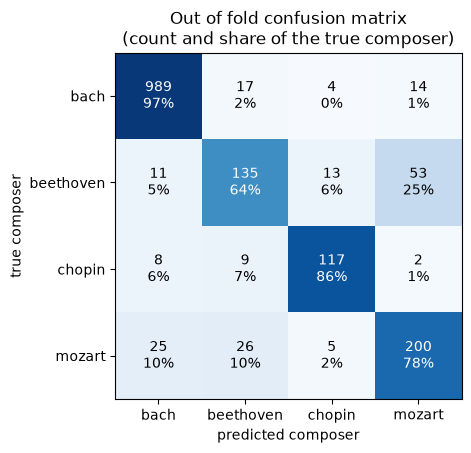

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(preds["composer"], preds["pred"], labels=COMPOSERS)
rates = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.imshow(rates, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(COMPOSERS)), COMPOSERS)
ax.set_yticks(range(len(COMPOSERS)), COMPOSERS)
for i in range(len(COMPOSERS)):
    for j in range(len(COMPOSERS)):
        ax.text(j, i, f"{cm[i, j]}\n{rates[i, j]:.0%}", ha="center", va="center",
                color="white" if rates[i, j] > 0.5 else "black")
ax.set_xlabel("predicted composer")
ax.set_ylabel("true composer")
ax.set_title("Out of fold confusion matrix\n(count and share of the true composer)")
plt.show()

Bach is nearly solved (97% recall) and the class weights protected Chopin, the smallest
class, at 86%. The error mass concentrates in the classical era pair: 25% of Beethoven
songs are predicted Mozart, and Mozart leaks 10% each to Bach and Beethoven. These look
like style and era confusions rather than random noise.

## Per composer precision, recall, and F1

The per class view behind macro-F1: precision is how often a predicted composer is
right, recall is how many of a composer's songs are found.

In [5]:
from sklearn.metrics import classification_report

print(classification_report(preds["composer"], preds["pred"], digits=3))

              precision    recall  f1-score   support

        bach      0.957     0.966     0.962      1024
   beethoven      0.722     0.637     0.677       212
      chopin      0.842     0.860     0.851       136
      mozart      0.743     0.781     0.762       256

    accuracy                          0.885      1628
   macro avg      0.816     0.811     0.813      1628
weighted avg      0.883     0.885     0.884      1628



The pooled macro-F1 of 0.813 agrees with the cross validation mean (0.812), as it should.
Beethoven is the weak class on both axes (precision 0.722, recall 0.637), while a "bach"
prediction is right 96% of the time. The 88.5% overall accuracy flatters the model because
Bach is 63% of the data, which is exactly why macro-F1 is the headline metric.

## Most confident mistakes

The wrong predictions the model was most sure about (confidence is the averaged window
probability of the predicted composer). These are the songs worth opening in a MIDI
player when writing the report's error analysis.

In [6]:
prob_cols = ["prob_bach", "prob_beethoven", "prob_chopin", "prob_mozart"]
errors = preds[preds["pred"] != preds["composer"]].copy()
errors["confidence"] = errors[prob_cols].max(axis=1)
print(f"{len(errors)} of {len(preds)} songs misclassified")
errors.sort_values("confidence", ascending=False)[
    ["filename", "composer", "pred", "confidence"]].head(10)

187 of 1628 songs misclassified


,filename,composer,pred,confidence
251,"19 Polish Songs, for Solo Voice and Piano acco...",chopin,bach,0.998997
605,K401 Fuga in G minor .mid,mozart,bach,0.997817
260,"19 Polish Songs, for Solo Voice and Piano acco...",chopin,bach,0.997017
586,"19 Polish Songs, for Solo Voice and Piano acco...",chopin,bach,0.987299
1229,Etude op25 n08.mid,chopin,bach,0.955804
779,15 Musette.mid,bach,chopin,0.942380
554,WoO061a Mouvement Pour Piano.mid,beethoven,bach,0.940587
592,"19 Polish Songs, for Solo Voice and Piano acco...",chopin,bach,0.937881
367,13 Marche.mid,bach,mozart,0.934025
411,Bwv0992 Capriccio.mid,bach,beethoven,0.931875


The worst errors are musically plausible, which makes them report material rather than
model bugs: half of the top ten are Chopin's "19 Polish Songs" (solo voice with piano
accompaniment, a texture unlike his solo piano writing) called Bach at up to 99.9%
confidence, and Mozart's K401, a fugue, is also called Bach, the model reading strict
counterpoint as its most Bach shaped evidence.

## Accuracy by song length

Training sees only one random 30 second crop per song per epoch and evaluation averages
fixed windows, so it is worth checking whether very short or very long songs suffer.
Songs are split into length quartiles (minutes at 10 frames per second).

In [7]:
preds["correct"] = preds["pred"] == preds["composer"]
preds["minutes"] = preds["n_frames"] / 10 / 60
preds["length_quartile"] = pd.qcut(preds["minutes"], 4)
by_length = preds.groupby("length_quartile", observed=True).agg(
    songs=("correct", "size"), accuracy=("correct", "mean"))
print(by_length.round(3))

# the pooled numbers above are confounded with composer (short songs are
# mostly Bach), so split accuracy by composer within each quartile too
preds.groupby(["length_quartile", "composer"], observed=True)[
    "correct"].mean().unstack().round(3)

                 songs  accuracy
length_quartile                 
(0.291, 0.85]      411     0.968
(0.85, 2.259]      403     0.903
(2.259, 5.454]     407     0.845
(5.454, 86.823]    407     0.823


composer,bach,beethoven,chopin,mozart
length_quartile,,,,
"(0.291, 0.85]",1.000,0.385,0.818,0.571
"(0.85, 2.259]",0.960,0.520,0.864,0.710
"(2.259, 5.454]",0.926,0.542,0.824,0.805
"(5.454, 86.823]",0.945,0.722,0.933,0.794


Raw accuracy falls from 97% for the shortest quartile to 82% for the longest, but the
composer split shows this is composition, not length: the shortest quartile is over 90%
Bach. Within each composer, accuracy is flat or improves with length (Beethoven climbs
from 39% on the shortest quartile to 72% on the longest, where evaluation has more
windows to average). The 30 second crop is not starving long songs; short Beethoven and
Mozart pieces are simply the hardest cases.

## Takeaways

- The recomputed fold scores match `summary.json` exactly, so everything above describes
  precisely the model that training reported: pooled macro-F1 0.813 over all 1,628 out of
  fold predictions, 187 songs misclassified.
- The model is a near perfect Bach detector and a strong Chopin detector; the remaining
  error mass concentrates in Beethoven vs Mozart, a genuinely harder distinction between
  two composers of the same era. Any future improvement effort should target that pair.
- The most confident mistakes have musical explanations (vocal Chopin called Bach, a
  Mozart fugue called Bach), and song length costs nothing once composer mix is controlled
  for. Together those argue the current representation is not the bottleneck: a finer
  time resolution (FS=20) would attack a problem the model does not have.